<a href="https://colab.research.google.com/github/jenriver/tiny-transformer/blob/main/tiny_transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import jax
import jax.numpy as jnp
import random
from collections.abc import Sequence

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [ ]:
jax.devices()

[TpuDevice(id=0, process_index=0, coords=(0,0,0), core_on_chip=0)]

In [ ]:
chars_str = "0123456789+="
pad_str = "_"
MAX_LEN = len("999+999=1998")

def make_vocab(chars_str: str):
  return list(pad_str + chars_str)
vocab = make_vocab(chars_str)
print(vocab)
pad_id = vocab.index(pad_str)

['_', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '+', '=']


In [ ]:
def encode(s_in: str) -> list[int]:
  output = []
  for s in s_in:
    output.append(vocab.index(s))
  return output

def decode(ids: list[int]) -> str:
  s = ""
  for i in ids:
    s += vocab[i]
  return s

def rand_ndigit(n):
    return random.randint(0, 9) if n == 1 else random.randint(10**(n-1), 10**n - 1)

def make_example(max_digits=3) -> str:
    a = rand_ndigit(random.randint(1, max_digits))
    b = rand_ndigit(random.randint(1, max_digits))
    return f'{a}+{b}={a+b}'

def make_input_target(ids):
  return ids[:-1], ids[1:]

def pad_to(ids: list[int], T: int) -> tuple[list[int], list[int]]:
  n = len(ids)
  padded = ids + [pad_id] * (T-n)
  mask = [1] * n + [0] * (T-n)
  return padded, mask

def make_batch(B: int, T: int):
  inputs, targets, masks = [], [], []
  for _ in range(B):
    ids = encode(make_example()) + [pad_id]  # important! varied length
    input, target = make_input_target(ids)
    input_padded, mask = pad_to(input, T)
    target_padded, _ = pad_to(target, T)
    inputs.append(input_padded)
    targets.append(target_padded)
    masks.append(mask)
  return jnp.array(inputs), jnp.array(targets), jnp.array(masks)

input = "12+34="
print(encode(input))
print(decode(encode(input)))

[2, 3, 11, 4, 5, 12]
12+34=


In [ ]:
def init_embed(key, V, D):
  return jax.random.normal(key, (V, D)) * (1.0 / jnp.sqrt(D))

def init_pos(key, T, D):
  return jax.random.normal(key, (T, D)) * (1.0 / jnp.sqrt(D))

def embed(table, ids):
  return table[ids]  # fancy-indexing gathers

In [ ]:
# @title MHA model init

def init_attn(key, D, N, K, H):
  kq, kk, kv, ko = jax.random.split(key, 4)
  scale = 1.0 / jnp.sqrt(D)
  return {
      "Wq": jax.random.normal(kq, (D, N, H)) * scale,
      "Wk": jax.random.normal(kk, (D, K, H)) * scale,
      "Wv": jax.random.normal(kv, (D, K, H)) * scale,
      "Wo": jax.random.normal(ko, (N, H, D)) * scale,
  }

def init_cache(B, S_max, K, H, L):
  return [{"k": jnp.zeros((B, S_max, K, H)),
           "v": jnp.zeros((B, S_max, K, H))} for _ in range(L)]

def attention(input: jnp.ndarray, attn: dict, cache = None, pos: int = 0):
  B, T, D = input.shape
  _, _, H = attn["Wq"].shape
  q = jnp.einsum("btd,dnh->btnh", input, attn["Wq"])
  k = jnp.einsum("bsd,dnh->bsnh", input, attn["Wk"])
  v = jnp.einsum("bsd,dnh->bsnh", input, attn["Wv"])

  if cache is not None:
    k = jax.lax.dynamic_update_slice(cache["k"], k, (0, pos, 0, 0))
    v = jax.lax.dynamic_update_slice(cache["v"], v, (0, pos, 0, 0))
    cache = {"k": k, "v": v}

  attn_matrix = jnp.einsum("btnh,bsnh->btsn", q, k) / jnp.sqrt(H)
  S = k.shape[1]
  q_pos  = pos + jnp.arange(T)
  kv_pos = jnp.arange(k.shape[1])
  causal = q_pos[:, None] >= kv_pos[None, :]
  # causal = jnp.tril(jnp.ones((T, S), dtype=bool))
  attn_matrix = jnp.where(causal[None, :, :, None], attn_matrix, -1e30)

  w = jax.nn.softmax(attn_matrix, axis=2)
  o = jnp.einsum("btsn,bsnh->btnh", w, v)
  return jnp.einsum("btnh,nhd->btd", o, attn["Wo"]), cache

def init_mlp(key, D, F):
  kw1, kw2, kw3 = jax.random.split(key, 3)
  return {
      "w_gate": jax.random.normal(kw1, (D, F)) / jnp.sqrt(D),
      "w_up":   jax.random.normal(kw2, (D, F)) / jnp.sqrt(D),
      "w_down": jax.random.normal(kw3, (F, D)) / jnp.sqrt(F),
  }

def mlp(input: jnp.ndarray, p: dict):
  B, T, D = input.shape
  gate = jnp.einsum("btd,df->btf", input, p["w_gate"])
  up =   jnp.einsum("btd,df->btf", input, p["w_up"])
  return jnp.einsum("btf,fd->btd", jax.nn.silu(gate) * up, p["w_down"])

def init_norm(D):
  return {'g': jnp.ones(D)}

def rmsnorm(x, p, eps=1e-6):
  ms = jnp.mean(x**2, axis=-1, keepdims=True)
  return x * jax.lax.rsqrt(ms + eps) * p["g"]

def init_block(key, D, N, K, H, F):
  ka, km = jax.random.split(key, 2)
  return {
      "attn": init_attn(ka, D, N, K, H),
      "mlp":   init_mlp(km, D, F),
      "norm1":  init_norm(D),
      "norm2":  init_norm(D),
  }

def init_blocks(key, D, N, K, H, F, L):
  return [init_block(kb, D, N, K, H, F) for kb in jax.random.split(key, L)]

def block(x: jnp.ndarray, p: dict, kvcache=None, pos=0):
  attn_out, kvcache = attention(rmsnorm(x, p['norm1']), p['attn'], kvcache, pos)
  x = x + attn_out
  x = x + mlp(rmsnorm(x, p['norm2']), p['mlp'])
  return x, kvcache

def init_model_dense(key, V, T, D, N, K, H, F, L):
  kt, kp, kb, ku = jax.random.split(key, 4)
  return {
      "tok_table": init_embed(kt, V, D),
      "pos_table": init_pos(kp, T, D),
      "blocks": init_blocks(kb, D, N, K, H, F, L),
      "norm": init_norm(D),
      "unembed": jax.random.normal(ku, (D, V)) / jnp.sqrt(D),
  }

def model_dense(ids, mp, kvcache=None, pos=0):
  T = ids.shape[1]
  x = mp["tok_table"][ids] + mp["pos_table"][pos + jnp.arange(T)]
  new_caches = []
  for i, p in enumerate(mp['blocks']):
    x, c = block(x, p, None if kvcache is None else kvcache[i], pos)
    new_caches.append(c)
  x = rmsnorm(x, mp['norm'])
  return jnp.einsum('btd,dv->btv', x, mp['unembed']), new_caches


In [ ]:
B = 128
T = MAX_LEN
D = 128
N = 4   # number of heads for query
H = 32  # 128 / 4 = 32 (head dim)
K = 4   # = N for MHA
F = 512 # 4 * D
L = 4
V = len(vocab)


ids, targets, masks = make_batch(B, T)
key = jax.random.PRNGKey(0)
params = init_model_dense(key, V, T, D, N, K, H, F, L)
x, _ = model_dense(ids, params)
print(decode(jnp.argmax(x, axis=-1)[0].tolist()))

00000_00_6_8


In [ ]:
print(sum(p.size for p in jax.tree.leaves(params)))
print(x.shape)  # B, T, V
print(jnp.isnan(x).any())

1054592
(128, 12, 13)
False


In [ ]:
print((V * D) + (T * D) + ((3 * D * F) + (4 * D * N * H) + (2 * D)) * L + D + (V * D))

1054592


In [ ]:
jit_model = jax.jit(model_dense)

def generate(params, prompt, T, K, H, L):
  caches = init_cache(1, T, K, H, L)
  ids = encode(prompt)
  logits, caches = jit_model(jnp.array([ids]), params, caches, 0)    # prefill: ONE call
  out = list(ids)
  for pos in range(len(ids), T):
    nxt = int(jnp.argmax(logits[0, -1]))
    if nxt == pad_id: break
    out.append(nxt)
    logits, caches = jit_model(jnp.array([[nxt]]), params, caches, pos)
  return decode(out)


def sample(params, prompt="456+789="): # "456+789="  # "12+34="
    ids_ = jnp.array([encode(prompt) + [pad_id]*(T-len(prompt))])
    for i in range(len(prompt), T):
        logits, _ = jit_model(ids_, params)
        nxt = jnp.argmax(logits[0, i-1])
        if nxt == pad_id: break  # early stopping
        ids_ = ids_.at[0, i].set(nxt)
    return decode(ids_[0].tolist()).split(pad_str)[0]  # rid padding to match.

for p in ["12+34=", "456+789=", "9+9=", "999+1=", "1+1="]:
    a, b = sample(params, p), generate(params, p, T, K, H, L)
    print(f"{'MATCH ' if a==b else 'DIFFER'} {p:10} {a!r:18} {b!r}")

MATCH  12+34=     '12+34=646444'     '12+34=646444'
MATCH  456+789=   '456+789=4'        '456+789=4'
MATCH  9+9=       '9+9=77777738'     '9+9=77777738'
MATCH  999+1=     '999+1=777777'     '999+1=777777'
MATCH  1+1=       '1+1=66666666'     '1+1=66666666'


## Training

In [ ]:
import numpy as np
import optax
import math

def loss_fn(params, ids, targets, mask):
  logits, _ = model_dense(ids, params)
  # logp = jax.nn.log_softmax(logits, axis=-1)
  # tgt = jnp.take_along_axis(logp, targets[..., None], -1)[..., 0]
  # return -(tgt * mask).sum() / mask.sum()
  ce = optax.softmax_cross_entropy_with_integer_labels(logits, targets)   # [B,T]
  return (ce * mask).sum() / mask.sum()

opt = optax.adamw(3e-4)
opt_state = opt.init(params)

@jax.jit
def train_step(params, opt_state, ids, targets, masks):
    loss, grads = jax.value_and_grad(loss_fn)(params, ids, targets, masks)
    gnorm = optax.global_norm(grads)  # ← is it actually learning?
    updates, opt_state = opt.update(grads, opt_state, params)
    return optax.apply_updates(params, updates), opt_state, loss, gnorm

@jax.jit
def accuracy(params, ids, targets, masks):
    logits, _ = model_dense(ids, params)
    pred = jnp.argmax(logits, -1)
    return ((pred == targets) * masks).sum() / masks.sum()


In [ ]:
init_loss = loss_fn(params, ids, targets, masks)

print(f'init loss {init_loss:.3f}  |  uniform baseline ln(V) = {math.log(V):.3f}  |  expected ≈ {math.log(V)+(1**2)/2:.3f}')

init loss 2.999  |  uniform baseline ln(V) = 2.565  |  expected ≈ 3.065


In [ ]:
PROBES = {
  "1d_nocarry": [(3,4),(1,2),(5,3),(2,6)],
  "1d_carry":   [(7,8),(9,6),(5,9),(8,4)],
  "2d_nocarry": [(12,34),(21,45),(53,26),(31,44)],
  "2d_carry":   [(18,34),(57,68),(29,13),(46,37)],
  "3d_nocarry": [(123,456),(321,234),(412,145)],
  "3d_carry":   [(456,789),(678,543),(199,282)],
  "cascade":    [(999,1),(99,1),(199,801),(909,91)],
}

def batch_generate(params, prompts):
    arr  = jnp.array([encode(p) + [pad_id]*(T-len(p)) for p in prompts])
    lens = jnp.array([len(p) for p in prompts])
    for i in range(int(lens.min()), T):
        logits, _ = model_dense(arr, params)
        nxt   = jnp.argmax(logits[:, i-1], -1)
        write = i >= lens                                   # don't overwrite prompts
        arr   = arr.at[:, i].set(jnp.where(write, nxt, arr[:, i]))
    return [decode(r.tolist()).split(pad_str)[0] for r in arr]   # cut at first PAD

def evaluate(params):
    flat = [(b,a,c) for b,ps in PROBES.items() for a,c in ps]
    outs = batch_generate(params, [f"{a}+{c}=" for _,a,c in flat])
    res  = {}
    for (b,a,c), out in zip(flat, outs):
        res.setdefault(b, []).append(out == f"{a}+{c}={a+c}")
    return {b: sum(v)/len(v) for b,v in res.items()}, dict(zip(
            [(a,c) for _,a,c in flat], [o == f"{a}+{c}={a+c}" for (_,a,c),o in zip(flat,outs)]))

def show_table(first_solve, PROBES, last_step):
    print(f"{'category':14}{'solved':>8}{'median':>9}{'range':>16}")
    print("─" * 47)
    for c, items in PROBES.items():
        steps = [first_solve[i] for i in items if i in first_solve]
        k, n = len(steps), len(items)
        med = int(np.median(steps)) if k else "—"
        rng = f"({min(steps)}–{max(steps)})" if k else "—"
        print(f"{c:14}{f'{k}/{n}':>8}{str(med):>9}{rng:>16}")
    print(f"\nunsolved = censored (>{last_step} steps) — don't drop them from the story")

# ---- trackers ----
emergence  = {b: [] for b in PROBES}     # (step, accuracy) curves
first_solve = {}                          # (a,b) -> step first solved

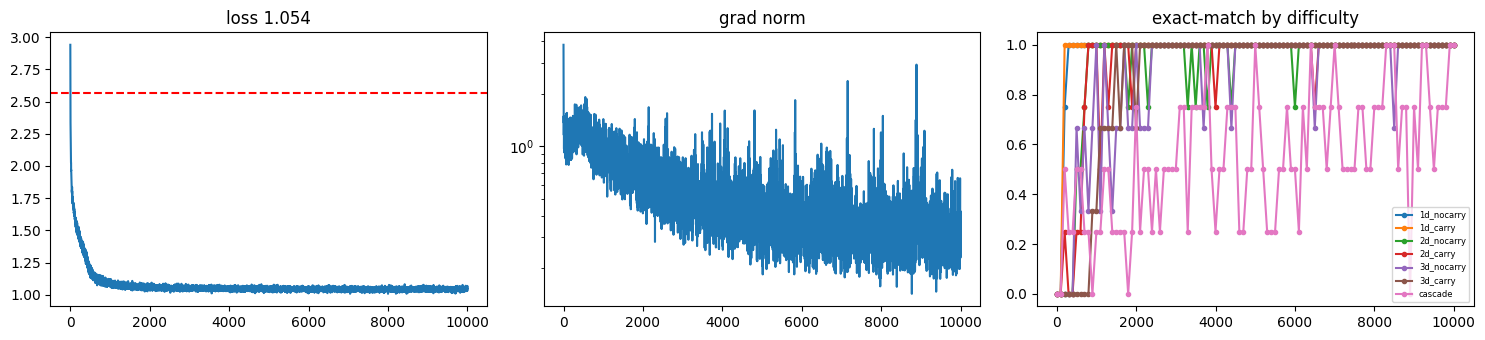

step 10000  sample: '456+789=1245'
{'1d_nocarry': '1.00', '1d_carry': '1.00', '2d_nocarry': '1.00', '2d_carry': '1.00', '3d_nocarry': '1.00', '3d_carry': '1.00', 'cascade': '1.00'}
category        solved   median           range
───────────────────────────────────────────────
1d_nocarry         4/4      200       (200–300)
1d_carry           4/4      200       (200–200)
2d_nocarry         4/4      600       (500–700)
2d_carry           4/4      550       (200–700)
3d_nocarry         3/3      500      (500–1000)
3d_carry           3/3     1100      (900–1500)
cascade            4/4      700      (200–2000)

unsolved = censored (>10000 steps) — don't drop them from the story


In [ ]:
import matplotlib.pyplot as plt, math
from IPython.display import clear_output

# ---------------- training loop ----------------
params  = init_model_dense(key, V, T, D, N, K, H, F, L)
opt     = optax.adamw(3e-4)
opt_state = opt.init(params)
hist = {"loss": [], "gnorm": [], "acc": []}
EVAL_EVERY = 100

for step in range(10001):
    ids, targets, masks = make_batch(B, T)                 # FRESH batch each step
    params, opt_state, loss, gnorm = train_step(params, opt_state, ids, targets, masks)
    hist["loss"].append(float(loss)); hist["gnorm"].append(float(gnorm))

    if step % EVAL_EVERY == 0:
        accs, per_ex = evaluate(params)
        for b, a in accs.items(): emergence[b].append((step, a))
        for prob, ok in per_ex.items():
            if ok and prob not in first_solve:
                first_solve[prob] = step
                print(f"step {step}: FIRST SOLVED {prob[0]}+{prob[1]}={prob[0]+prob[1]}")

        clear_output(wait=True)
        fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
        ax[0].plot(hist["loss"]); ax[0].axhline(math.log(V), ls='--', c='r'); ax[0].set_title(f"loss {loss:.3f}")
        ax[1].plot(hist["gnorm"]); ax[1].set_yscale('log'); ax[1].set_title("grad norm")
        for b, pts in emergence.items():
            if pts: ax[2].plot(*zip(*pts), marker='o', ms=3, label=b)
        ax[2].set_ylim(-.05,1.05); ax[2].legend(fontsize=6); ax[2].set_title("exact-match by difficulty")
        plt.tight_layout(); plt.show()
        print(f"step {step}  sample: {sample(params)!r}")
        print({b: f"{a:.2f}" for b,a in accs.items()})

show_table(first_solve, PROBES, 10000)

In [ ]:
# @title Fit Chinchilla Scaling Law
"""
L(P, Tok) =        E        +      A/P^α       +      B/Tok^β
               can never         too small a        haven't seen
               remove            model              enough data

- E: irreducible entropy of language. Perfect model at infinite data hits ~0.

P varied by manipulating d_model and layers
toks varied based on training steps
"""

def make_train_step(opt):
  @jax.jit
  def train_step(params, opt_state, ids, targets, masks):
      loss, grads = jax.value_and_grad(loss_fn)(params, ids, targets, masks)
      gnorm = optax.global_norm(grads)
      updates, opt_state = opt.update(grads, opt_state, params)
      return optax.apply_updates(params, updates), opt_state, loss, gnorm
  return train_step

@jax.jit
def accuracy(params, ids, targets, masks):
    logits, _ = model_dense(ids, params)
    pred = jnp.argmax(logits, -1)
    return ((pred == targets) * masks).sum() / masks.sum()

def train_run(d_model, n_layers, train_steps=1500, lr=3e-4, B=128, eval_every=250):
  n_heads, d_ff = max(1, d_model // H), 4 * d_model
  params = init_model_dense(key, V, T, d_model, n_heads, n_heads, H, d_ff, n_layers)
  n_params = sum(p.size for p in jax.tree.leaves(params))
  opt = optax.adamw(lr); opt_state = opt.init(params)
  step_fn = make_train_step(opt)
  eval_ids, eval_tg, eval_mk = make_batch(512, T)
  rows = []
  for step in range(1, train_steps + 1):
      ids, targets, masks = make_batch(B, T)
      params, opt_state, loss, gnorm = step_fn(params, opt_state, ids, targets, masks)
      if step % eval_every == 0:
          rows.append(dict(P=n_params, tok=B*T*step,
                           loss=float(loss_fn(params, eval_ids, eval_tg, eval_mk)),
                           gnorm=float(gnorm)))
  return rows

params_varied = [
    (64,  2),   #    134K
    (96,  2),   #    299K
    (128, 2),   #    530K
    (192, 2),   #   1.19M
    (256, 2),   #   2.11M
    (128, 4),   #   1.05M
    (192, 4),   #   2.37M
    (256, 4),   #   4.21M
    (320, 4),   #   6.57M
    (384, 6),   #   14.2M
]
sweep = []
for d_model, n_layers in params_varied:
    sweep += train_run(d_model, n_layers, train_steps=5000)
    print(f'sweeps added (-10): {sweep[-10:]}')


sweeps added (-10): [{'P': 133824, 'tok': 4224000, 'loss': 1.1606699228286743, 'gnorm': 1.0105481147766113}, {'P': 133824, 'tok': 4608000, 'loss': 1.1462262868881226, 'gnorm': 1.1128798723220825}, {'P': 133824, 'tok': 4992000, 'loss': 1.1383328437805176, 'gnorm': 0.9043148756027222}, {'P': 133824, 'tok': 5376000, 'loss': 1.1408621072769165, 'gnorm': 0.8879965543746948}, {'P': 133824, 'tok': 5760000, 'loss': 1.1275711059570312, 'gnorm': 1.8418110609054565}, {'P': 133824, 'tok': 6144000, 'loss': 1.1258387565612793, 'gnorm': 0.9270297288894653}, {'P': 133824, 'tok': 6528000, 'loss': 1.1244158744812012, 'gnorm': 1.0550950765609741}, {'P': 133824, 'tok': 6912000, 'loss': 1.1208051443099976, 'gnorm': 0.9483113884925842}, {'P': 133824, 'tok': 7296000, 'loss': 1.1168841123580933, 'gnorm': 0.8049065470695496}, {'P': 133824, 'tok': 7680000, 'loss': 1.0967772006988525, 'gnorm': 0.6799379587173462}]
sweeps added (-10): [{'P': 299040, 'tok': 4224000, 'loss': 1.0814447402954102, 'gnorm': 0.766754448

In [ ]:
from scipy.optimize import curve_fit

sweep_P, sweep_tok, sweep_loss = zip(*[(r['P'], r['tok'], r['loss']) for r in sweep])
sweep_P = np.array(sweep_P) / 1e6
sweep_tok = np.array(sweep_tok) / 1e6

print(f'sweep_P: {sweep_P}')
print(f'sweep_tok: {sweep_tok}')

def chinchilla_law(X, E, A, B, alpha, beta):
    P, tok = X
    return E + A/P**alpha + B/tok**beta

(E, A, B, alpha, beta), _ = curve_fit(chinchilla_law, (sweep_P, sweep_tok), sweep_loss, p0=[0.1, 1, 1, 0.3, 0.3], maxfev=100000)

print(E, A, B, alpha, beta)

for i in range(len(sweep)):
  true_loss = sweep_loss[i]
  pred_loss = E + A/sweep_P[i]**alpha + B/sweep_tok[i]**beta
  print(f'true loss: {true_loss} vs. predicted loss: {pred_loss}')

sweep_P: [ 0.133824  0.133824  0.133824  0.133824  0.133824  0.133824  0.133824
  0.133824  0.133824  0.133824  0.133824  0.133824  0.133824  0.133824
  0.133824  0.133824  0.133824  0.133824  0.133824  0.133824  0.29904
  0.29904   0.29904   0.29904   0.29904   0.29904   0.29904   0.29904
  0.29904   0.29904   0.29904   0.29904   0.29904   0.29904   0.29904
  0.29904   0.29904   0.29904   0.29904   0.29904   0.529792  0.529792
  0.529792  0.529792  0.529792  0.529792  0.529792  0.529792  0.529792
  0.529792  0.529792  0.529792  0.529792  0.529792  0.529792  0.529792
  0.529792  0.529792  0.529792  0.529792  1.187904  1.187904  1.187904
  1.187904  1.187904  1.187904  1.187904  1.187904  1.187904  1.187904
  1.187904  1.187904  1.187904  1.187904  1.187904  1.187904  1.187904
  1.187904  1.187904  1.187904  2.10816   2.10816   2.10816   2.10816
  2.10816   2.10816   2.10816   2.10816   2.10816   2.10816   2.10816
  2.10816   2.10816   2.10816   2.10816   2.10816   2.10816   2.10816
  2

dense: alpha=0.959 beta=0.992 E=0.993 -> U possible


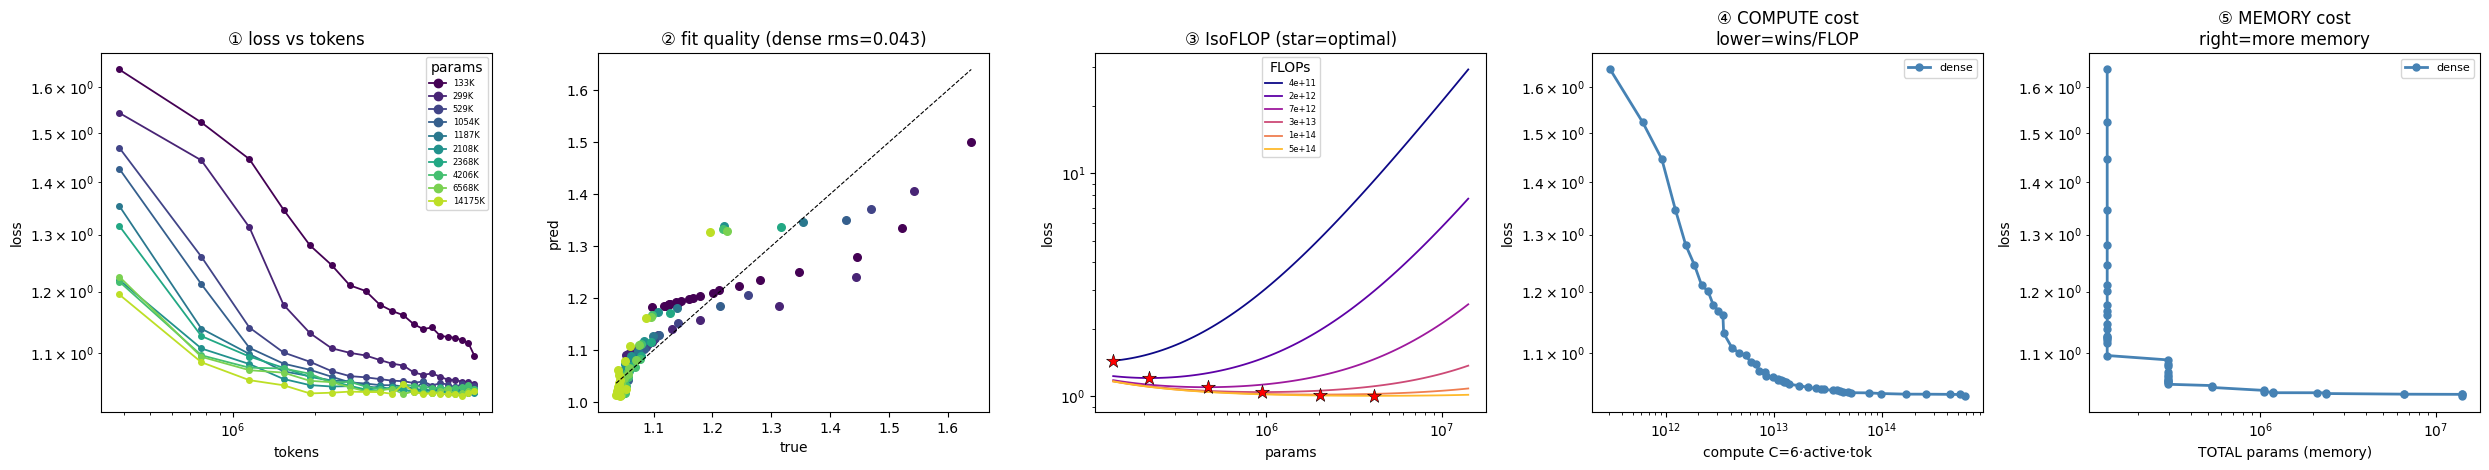

In [ ]:
import numpy as np, matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from matplotlib.lines import Line2D

def chinchilla_law(X,E,A,B,al,be): P,tok=X; return E+A/P**al+B/tok**be

def fit_law(P,tok,loss):
    lo=[0,0,0,1e-3,1e-3]; hi=[min(loss),1e3,1e3,1,1]
    return curve_fit(chinchilla_law,(P/1e6,tok/1e6),loss,
                     p0=[min(loss),1,1,.3,.3],bounds=(lo,hi),maxfev=200000)[0]

def _front(x,loss):
    o=np.argsort(x); best=np.inf; fx,fl=[],[]
    for xx,ll in zip(np.asarray(x)[o],np.asarray(loss)[o]):
        if ll<best: best=ll; fx.append(xx); fl.append(ll)
    return fx,fl

def chinchilla_report(sweep, label="dense", ls="-", axes=None):
    P    = np.array([r['P']                 for r in sweep], float)   # active (FLOP)
    Ptot = np.array([r.get('total', r['P']) for r in sweep], float)   # total (memory)
    tok  = np.array([r['tok']  for r in sweep], float)
    loss = np.array([r['loss'] for r in sweep], float)
    E,A,B,al,be = fit_law(P,tok,loss)
    print(f"{label}: alpha={al:.3f} beta={be:.3f} E={E:.3f} -> "
          f"{'U possible' if al>0.15 else 'alpha~0: NO U (saturated)'}")

    sizes = sorted(set(P)); cmap = plt.cm.viridis(np.linspace(0,.9,len(sizes)))
    csize = {s:c for s,c in zip(sizes,cmap)}
    if axes is None: _, axes = plt.subplots(1,5, figsize=(25,4.8))
    ax = axes

    # ① loss vs tokens -- color = size
    for s in sizes:
        m=P==s; ax[0].plot(tok[m], loss[m], ls, color=csize[s], marker="o", ms=4, lw=1.3)
    ax[0].set(xscale="log",yscale="log",xlabel="tokens",ylabel="loss",title="① loss vs tokens")

    # ② pred vs true -- color = size
    pred=chinchilla_law((P/1e6,tok/1e6),E,A,B,al,be); rms=np.sqrt(np.mean((pred-loss)**2))
    for s in sizes:
        m=P==s; ax[1].scatter(loss[m],pred[m],color=csize[s],s=30)
    lo,hi=loss.min(),loss.max(); ax[1].plot([lo,hi],[lo,hi],"k--",lw=.8)
    ax[1].set(xlabel="true",ylabel="pred",title=f"② fit quality ({label} rms={rms:.3f})")

    # ③ IsoFLOP from fit -- color = budget
    C=6*P*tok; budgets=np.logspace(np.log10(C.min()*1.2),np.log10(C.max()*.8),6)
    Ng=np.logspace(np.log10(P.min()),np.log10(P.max()),80)
    for c,Cb in zip(plt.cm.plasma(np.linspace(0,.85,6)),budgets):
        Dg=Cb/(6*Ng); L=chinchilla_law((Ng/1e6,Dg/1e6),E,A,B,al,be)
        ax[2].plot(Ng,L,ls,color=c,lw=1.3,label=f"{Cb:.0e}")
        i=np.argmin(L); ax[2].scatter(Ng[i],L[i],color="red",marker="*",s=110,zorder=5,edgecolor="k",lw=.4)
    ax[2].set(xscale="log",yscale="log",xlabel="params",ylabel="loss",title="③ IsoFLOP (star=optimal)")
    ax[2].legend(fontsize=6,title="FLOPs",loc="upper center")

    # ④ compute frontier
    col = "crimson" if label=="MoE" else "steelblue"
    fx,fl=_front(C,loss); ax[3].plot(fx,fl,ls,color=col,marker="o",ms=5,lw=2,label=label)
    ax[3].set(xscale="log",yscale="log",xlabel="compute C=6·active·tok",ylabel="loss",
              title="④ COMPUTE cost\nlower=wins/FLOP"); ax[3].legend(fontsize=8)

    # ⑤ memory frontier
    fx,fl=_front(Ptot,loss); ax[4].plot(fx,fl,ls,color=col,marker="o",ms=5,lw=2,label=label)
    ax[4].set(xscale="log",yscale="log",xlabel="TOTAL params (memory)",ylabel="loss",
              title="⑤ MEMORY cost\nright=more memory"); ax[4].legend(fontsize=8)

    # legends: size (colors) on ①, architecture (line style) on ②
    size_handles=[Line2D([0],[0],color=csize[s],marker="o",lw=1.3,label=f"{int(s/1e3)}K") for s in sizes]
    ax[0].legend(handles=size_handles,fontsize=6,title="params",loc="upper right")
    return axes

# dense solid, MoE dashed, overlaid on same axes:
ax = chinchilla_report(sweep, "dense", "-")
# ax = chinchilla_report(sweep_moe, "MoE", "--", axes=ax)
plt.tight_layout(); plt.show()